> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy


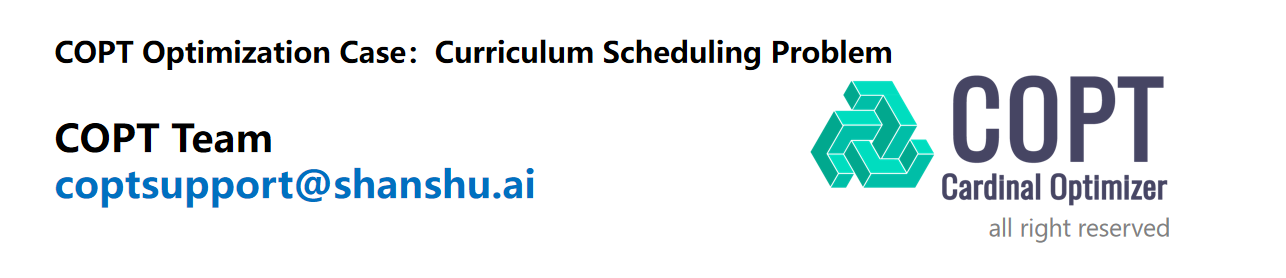

# Curriculum Scheduling Problem Code Implementation
# Steps to model and solve the MIP problem

First, let’s sort out the basic steps of calling COPT in Python to model and solve the MIP problem:

1. Import the `coptpy` package

2. For abstract models, add/import model test **data**

3. Create **Solving Environment** and Solving **Model**

4. Build the model and add the **three elements of the model** in sequence

- Add **decision variables**: integer type (or 0-1 type) and continuous type
- Set **objective function**
- Add **constraints**

5. Set **Solution Parameters** and **Solve**

6. View and analyze solution **results**


## Create COPT environment and model

These are the necessary steps before calling COPT modeling and solving in Python:

In [2]:
from coptpy import *
# Create environment
env = Envr()

# Create model 
model = env.createModel(name="course_scheduling")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add test data
**1. Dictionary: key (course, teacher),
value rating and time period**

In [4]:
instructor, instructorRating, instructorTime = multidict({
    ('MGT 490', 1): [4.3, [('Mon', 4)]],
    ('MGT 490', 2): [3.8, [('Tues', 4)]],
    ('MGT 490', 3): [3.5, [('Wed', 4)]],
    ('MGT 490', 4): [3.5, [('Fri', 4)]],
    ('MGT 490', 5): [4.6, [('Mon', 1), ('Wed', 2)]],
    ('MGT 490', 6): [2.7, [('Tues', 2), ('Thur', 1)]],
    ('FIN 358', 1): [3.5, [('Wed', 4)]],
    ('FIN 358', 2): [3.3, [('Tues', 2), ('Thur', 1)]],
    ('CIS 102T', 1): [4.4, [('Wed', 3)]],
    ('CIS 102T', 2): [3.1, [('Thur', 3)]],
    ('CIS 102W', 1): [3.7, [('Tues', 4)]],
    ('CIS 102W', 2): [3.5, [('Wed', 3)]],
    ('FIN 325', 1): [3.0, [('Thur', 4)]],
    ('FIN 325', 2): [3.7, [('Mon', 1), ('Wed', 2)]],
    ('FIN 352', 1): [3.6, [('Mon', 4)]],
    ('FIN 352', 2): [3.9, [('Mon', 2), ('Wed', 1)]],
    ('FIN 356', 1): [3.2, [('Tues', 4)]],
    ('FIN 356', 2): [3.4, [('Tues', 2), ('Thur', 1)]],
    ('FIN 359', 1): [3.0, [('Mon', 4)]],
    ('FIN 359', 2): [3.5, [('Wed', 4)]],
}) 

**<big><font color="#3c70c6">Tips</font></big>**

Here we use the auxiliary function ``multidict(data)``, which is used to split the input dictionary object ``data`` into keys and multiple new dictionary objects and return them;

Among them: ``instructor`` is the split ``key``, ``instructorRating`` and ``instructorTime`` new dictionary objects, which represent the course rating and course time period respectively.

**2. Course List**

Four list objects are added here, representing different types of courses.

In [6]:
compulsoryCourse = ['MGT 490', 'FIN 358']
cisOptionalCourse = ['CIS 102T', 'CIS 102W']
finOptionalCourse = ['FIN 325', 'FIN 352', 'FIN 356', 'FIN 359']
optionalCourse = cisOptionalCourse + finOptionalCourse

**3. Reverse dictionary: key (week, time period), value (course, teacher)**

In order to facilitate adding constraints on time period limits, corresponding to the previous dictionary object, here we create another "reverse dictionary", ``key`` is a tuple consisting of (week, time period), and ``value `` is (course, teacher).

In this way, when adding constraints later, you can easily locate the courses one by one by traversing the time period.

In [8]:
weekdays = ['Mon', 'Tues', 'Wed', 'Thur', 'Fri']
timeInstructor = dict()
for w in weekdays:
    for j in [1,2,3,4]:
        timeInstructor[(w, j)] = []
for i in instructor:
    for t in instructorTime[i]:
        timeInstructor[t].append(i)

## Add three elements of the model

**Add decision variables**

Add decision variables in batches here: ``instructor`` represents the subscript of the variable, which is a ``tuple`` composed of (course number, teacher number), specifies the variable type ``vtype=COPT.BINARY``, and adds 0- 1 Decision variable ``x``.


In [10]:
x = model.addVars(instructor, vtype=COPT.BINARY)

**Set objective function**

Set the objective function to the total score of the selected course, and ``sense`` specifies the optimization direction as ``COPT.MAXIMIZE``.

In [12]:
model.setObjective(quicksum(instructorRating[i] * x[i] for i in instructor), sense=COPT.MAXIMIZE)

**Add constraints**

The six constraints listed during modeling are added in sequence, which are:


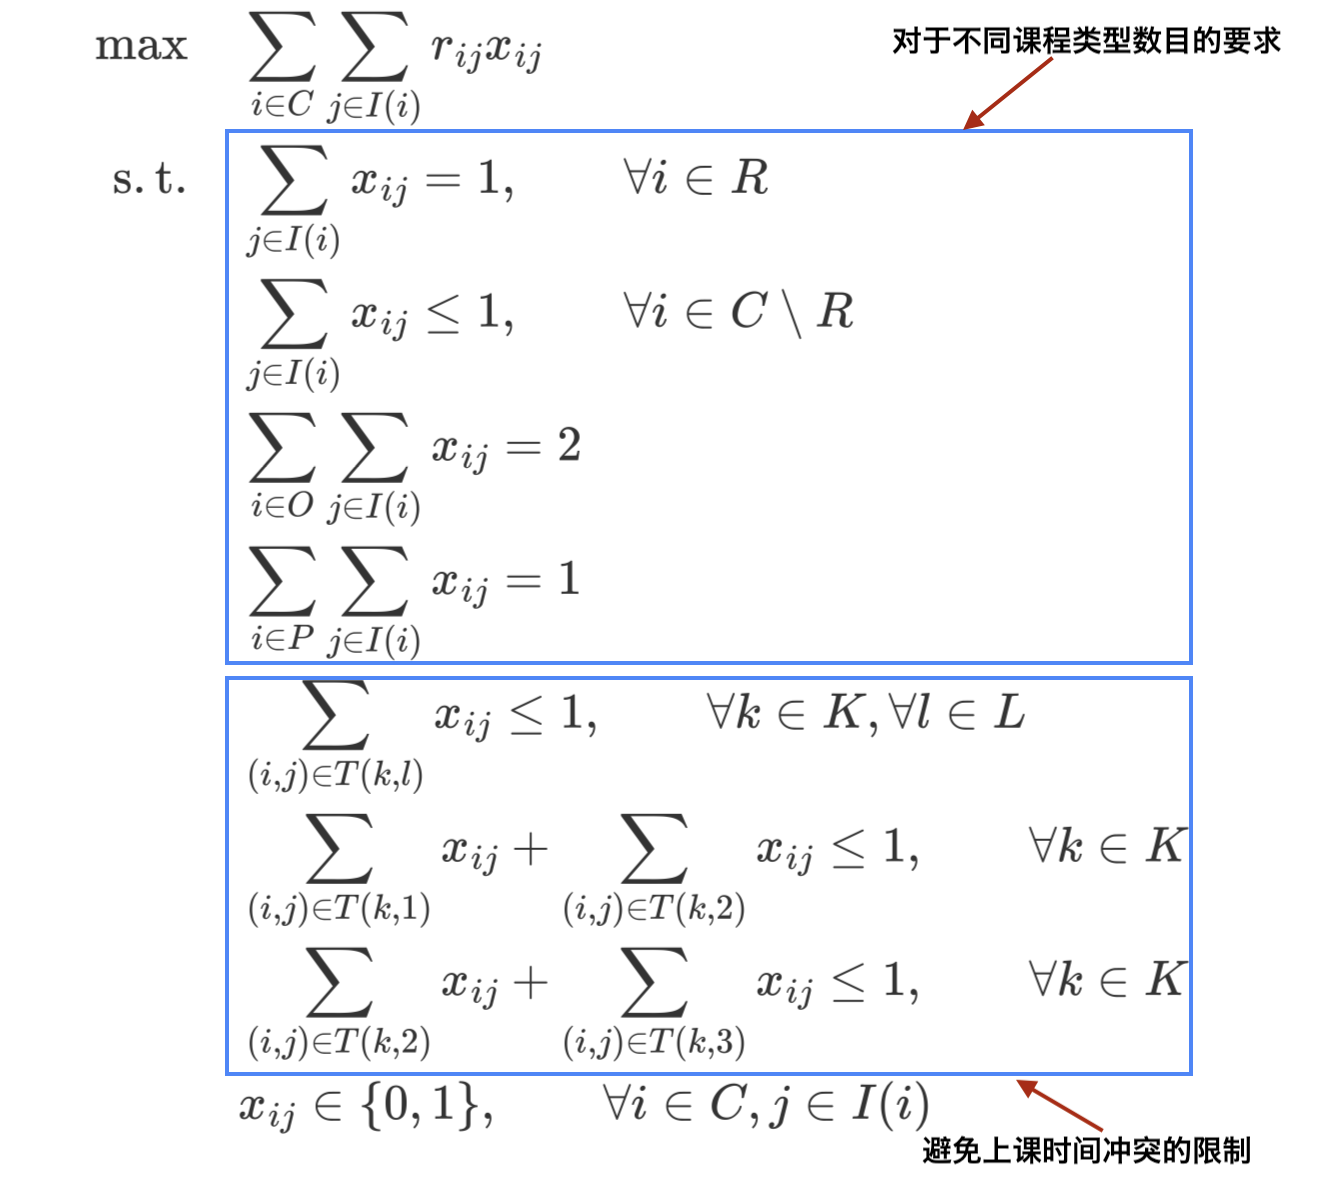

- Add constraints on the number of different course types required:

In [14]:
model.addConstrs(quicksum(x[i] for i in instructor if i[0] == c) == 1 for c in compulsoryCourse)
model.addConstrs(quicksum(x[i] for i in instructor if i[0] == c) <= 1 for c in optionalCourse) 
model.addConstr(quicksum(x[i] for i in instructor for c in cisOptionalCourse if i[0] == c) == 1)
model.addConstr(quicksum(x[i] for i in instructor for c in finOptionalCourse if i[0] == c) == 2)
print("Number of constraints in the current model：{}".format(model.getAttr("Rows")))

Number of constraints in the current model：10


- Add constraints to avoid time period conflict restrictions:

In [16]:
model.addConstrs(quicksum(x[i] for i in timeInstructor[t]) <= 1 for t in timeInstructor.keys())
model.addConstrs(quicksum(x[i] for i in timeInstructor[(k,1)] + timeInstructor[(k,2)]) <= 1 for k in weekdays)
model.addConstrs(quicksum(x[i] for i in timeInstructor[(k,2)] + timeInstructor[(k,3)]) <= 1 for k in weekdays)
print("Number of constraints in the current model：{}".format(model.getAttr("Rows")))

Number of constraints in the current model：40


**<big><font color="#3c70c6">Tips</font></big>**

**1. It is recommended to use ``quicksum()``:**

When constructing linear and quadratic expressions, ``quicksum(data)`` optimizes the summation process, which is much better in performance than directly using the plus operator, where ``data`` is used to form linear expressions. All terms to be added in the formula;

**2. Modeling method of batch addition:**
- When modeling here, we used ``Model.addVars(instructor)`` to add decision variables in batches, and the subscript of the provided variable is ``instructor``;
- **Add constraints in batches** use ``Model.addConstrs(generator)``, where ``generator`` is a loop structure, each item of which is a constraint to be added.

## Solve and obtain results

After the modeling is completed, call the ``Model.solve()`` function to solve it.

In [18]:
# Solve the model
model.solve()

Model fingerprint: e28dc7e9

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    40 rows, 20 columns and 79 non-zero elements
    20 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    12 rows, 13 columns and 35 non-zero elements
    13 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,2e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [3e-01,4e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  4.130000e+01            --     Inf  0.06s
H        0         1      --       0  4

Finally, based on the solution results of the model, we could print out the selected course schedule (with time period and scoring):

In [20]:
# Time mapping
timeCode = {
    1: "1:25-2:20 p.m.",
    2: "1:25-3:15 p.m.",
    3: "2:30-5:15 p.m.",
    4: "6:00-8:45 p.m."
}
# Get results
if model.status == COPT.OPTIMAL:
    print("Optimal Objective (Total Course Rating) : {:4f}".format(model.objval) )
    print("-"*58)
    print("|     course\t |     rating\t |         time\t\t |")
    for i in instructor:
        if x[i].x >= 1e-6:
            timeList = instructorTime[i]
            print("-"*58)
            print("|    {0}\t |      {1}\t | {2}  {3}\t |".format(i[0], instructorRating[i], timeList[0][0], timeCode[timeList[0][1]]))
            if len(timeList) > 1:
                print("|\t\t |\t\t | {2}  {3}\t |".format(i[0], instructorRating[i], timeList[1][0], timeCode[timeList[1][1]]))
    print("-"*58)

Optimal Objective (Total Course Rating) : 19.500000
----------------------------------------------------------
|     course	 |     rating	 |         time		 |
----------------------------------------------------------
|    MGT 490	 |      4.3	 | Mon  6:00-8:45 p.m.	 |
----------------------------------------------------------
|    FIN 358	 |      3.5	 | Wed  6:00-8:45 p.m.	 |
----------------------------------------------------------
|    CIS 102T	 |      4.4	 | Wed  2:30-5:15 p.m.	 |
----------------------------------------------------------
|    FIN 352	 |      3.9	 | Mon  1:25-3:15 p.m.	 |
|		 |		 | Wed  1:25-2:20 p.m.	 |
----------------------------------------------------------
|    FIN 356	 |      3.4	 | Tues  1:25-3:15 p.m.	 |
|		 |		 | Thur  1:25-2:20 p.m.	 |
----------------------------------------------------------


**<big><font color="#3c70c6">Tips</font></big>**

By accessing the member properties of the Model class, you can directly obtain the solution results (the property names are case-independent):
- ``model.status``: Get the model solution status
- ``model.objval``: Obtain the optimal value of the objective function
- ``model.x``: Get the value of the decision variable

# References
[1] Janice K. Winch, Jack Yurkiewicz (2014) Case—Kelly’s Class Scheduling. INFORMS Transactions on Education 15(1):148-149.
http://dx.doi.org/10.1287/ited.2014.0128cs